In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

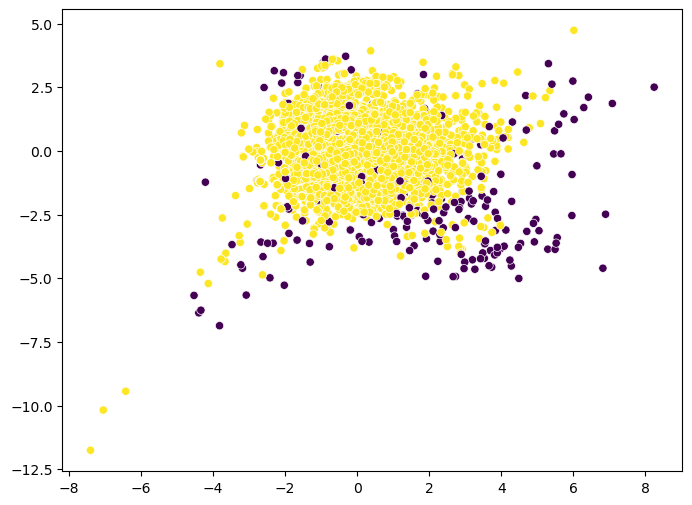

In [22]:
df = pd.read_csv('thyroid_dataset.csv')
X = df.drop(columns=['Outlier_label'])
y = df['Outlier_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = IsolationForest(n_estimators=200, contamination=0.036, random_state=42)
labels = clf.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], c=labels)
# labels

In [23]:
outliers = np.sum(labels == -1)
normal = np.sum(labels == 1)

print(f'Outliers: {outliers}')
print(f'normal: {normal}')

Outliers: 249
normal: 6667


Text(0, 0.5, 'PC2')

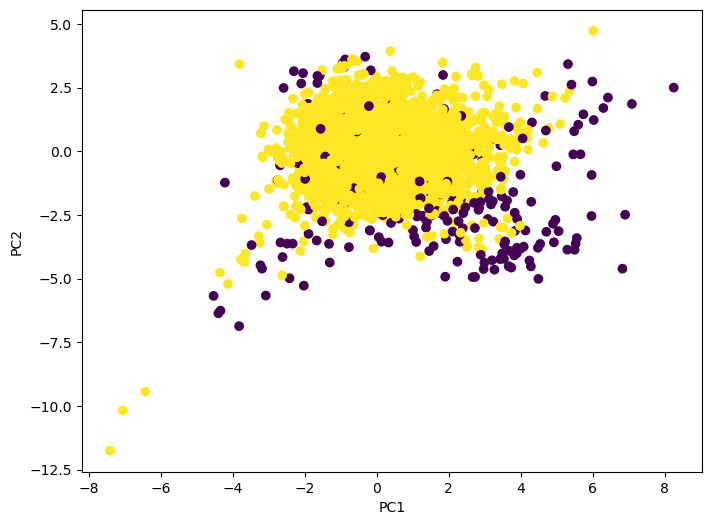

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel('PC1')
plt.ylabel('PC2')

In [27]:
from sklearn.neighbors import LocalOutlierFactor

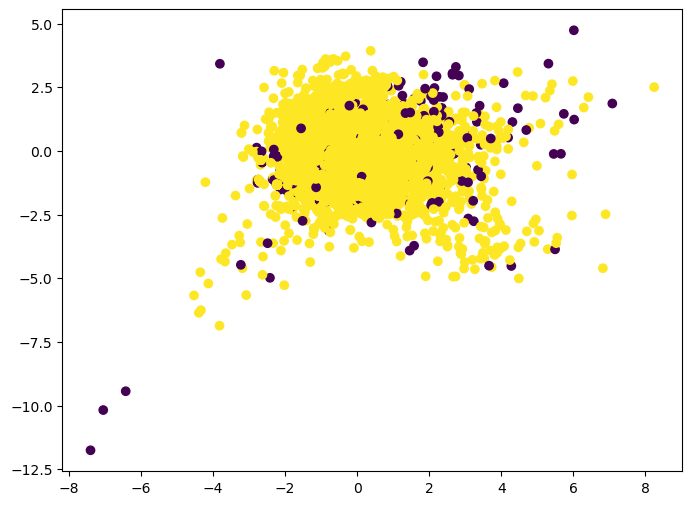

In [30]:
neighbors = LocalOutlierFactor(contamination=0.036)
labels = neighbors.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

In [31]:
outliers = np.sum(labels == -1)
normal = np.sum(labels == 1)

print(f'Outliers: {outliers}')
print(f'normal: {normal}')

Outliers: 249
normal: 6667
